## analyzing dispersal weight modeling

In [3]:
from dispersal_weight_generator import *
dispgen = dispersal_weight_generator()
weights_collection = []
topk_w_collection = []
K = 3
C_collection = []
for i in range(3,11,1): # npatch 
    weights_perpatch = []
    incoming_ws_perpatch = []
    C_perpatch = []
    for j in range(100): # sample siz
        sample = dispgen.uniform_dist(i, normalization=2)
        # calculte top k weights and connectivity
        incoming_ws_persample = []
        connectivity_persample = []
        for k in range(sample.shape[0]):
            incoming_w = sample[:,k].copy()
            incoming_w[k] = 0
            topk = np.sort(incoming_w)[-K:]          # K largest
            incoming_ws_persample.append(topk)
            connectivity = np.sum(incoming_w)
            connectivity_persample.append(connectivity)
        incoming_ws_persample = np.concatenate(np.array(incoming_ws_persample))
        connectivity_persample = np.array(connectivity_persample)

        # sample is a diagonally symetric matrix get above diagonals only as an array
        upper_triangular = np.triu(sample, k=1)
        weights = upper_triangular[upper_triangular != 0]
        weights_perpatch.append(weights)
        incoming_ws_perpatch.append(incoming_ws_persample)
        C_perpatch.append(connectivity_persample)
    weights_collection.append(np.concatenate(np.array(weights_perpatch)))
    topk_w_collection.append(np.concatenate(np.array(incoming_ws_perpatch)))
    C_collection.append(np.concatenate(np.array(C_perpatch)))



NameError: name 'topk_w_collection' is not defined

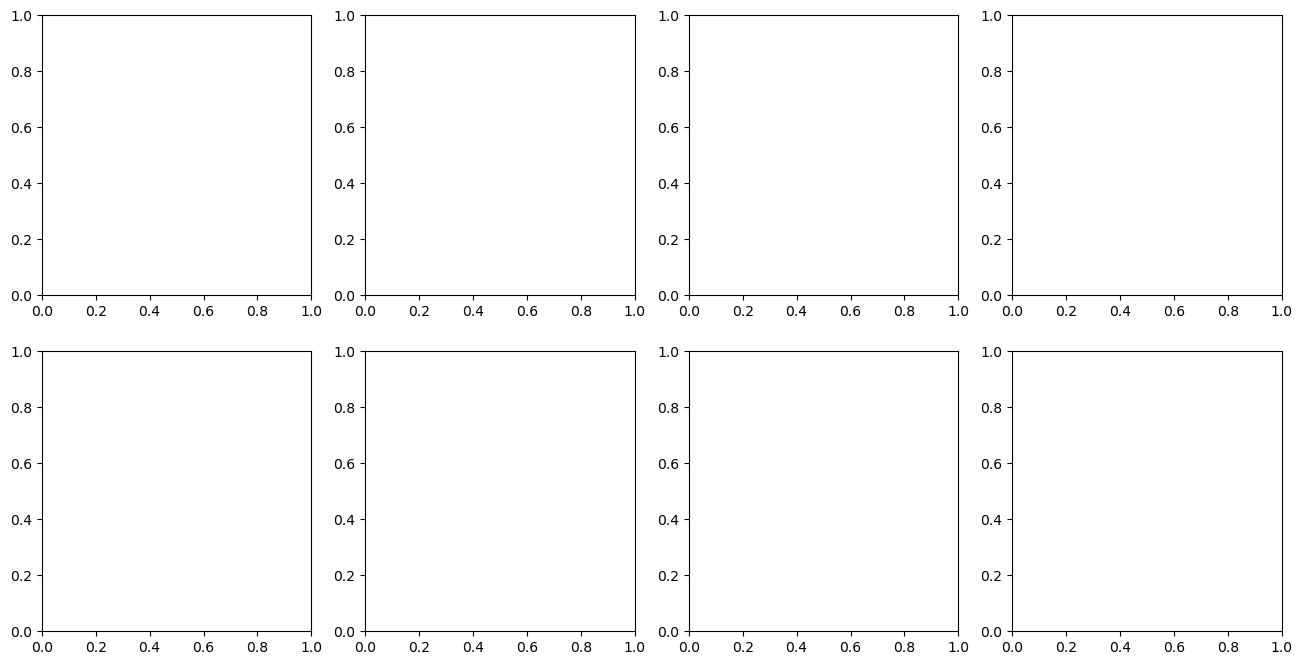

In [2]:
import matplotlib.pyplot as plt
# plot the distribution of top 3 incoming weights per patch in 2x4 subplots
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i in range(len(topk_w_collection)):
    ax = axes[i]
    ax.hist(topk_w_collection[i], bins=50, density=True)
    ax.set_title(f'top 3 incoming weights per patch. npatch={i+3}')
    ax.set_xlabel('Weight')
    ax.set_ylabel('Density')
# Hide any unused subplots
for j in range(len(topk_w_collection), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt
# plot the distribution of connectivity in 2x4 subplots
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i in range(len(C_collection)):
    ax = axes[i]
    ax.hist(C_collection[i], bins=50, density=True)
    ax.set_title(f'Connectivity distribution for npatch={i+3}')
    ax.set_xlabel('Connectivity')
    ax.set_ylabel('Density')
# Hide any unused subplots
for j in range(len(C_collection), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

NameError: name 'weights_collection' is not defined

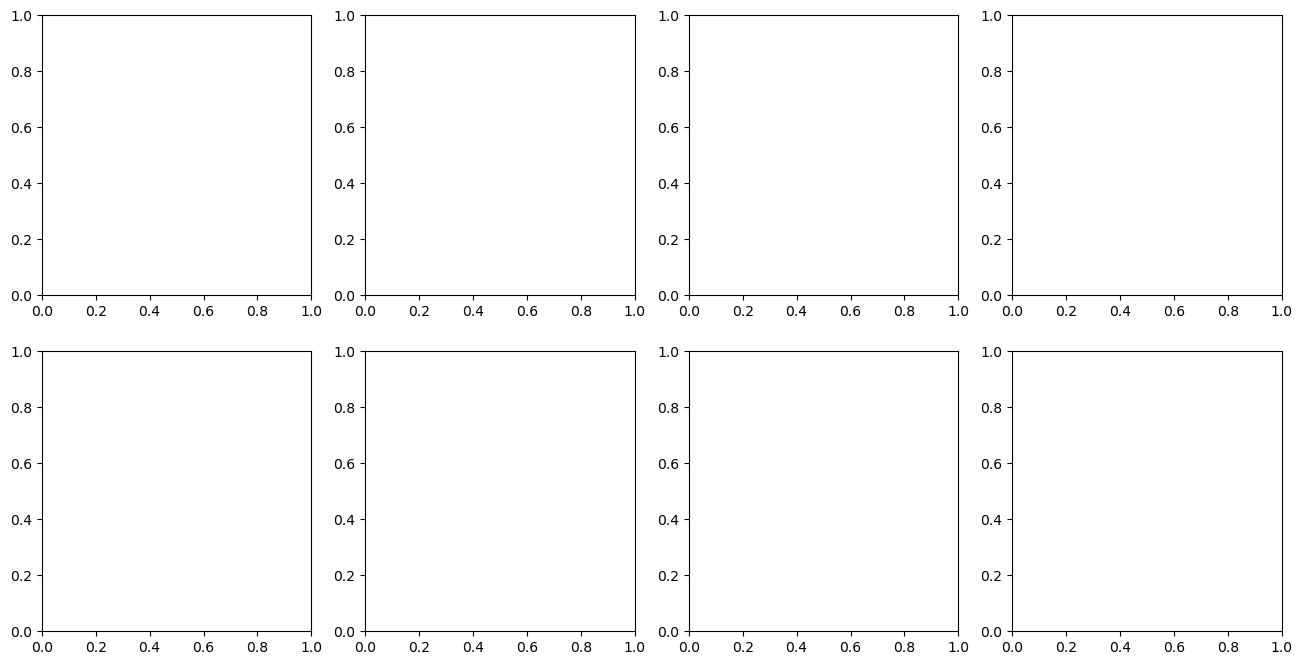

In [1]:
import matplotlib.pyplot as plt
# plot the distribution of weights for each npatch in 2x4 subplots
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i in range(len(weights_collection)):
    ax = axes[i]
    ax.hist(weights_collection[i], bins=50, density=True)
    ax.set_title(f'Weight distribution for npatch={i+3}')
    ax.set_xlabel('Weight')
    ax.set_ylabel('Density')
# Hide any unused subplots
for j in range(len(weights_collection), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()



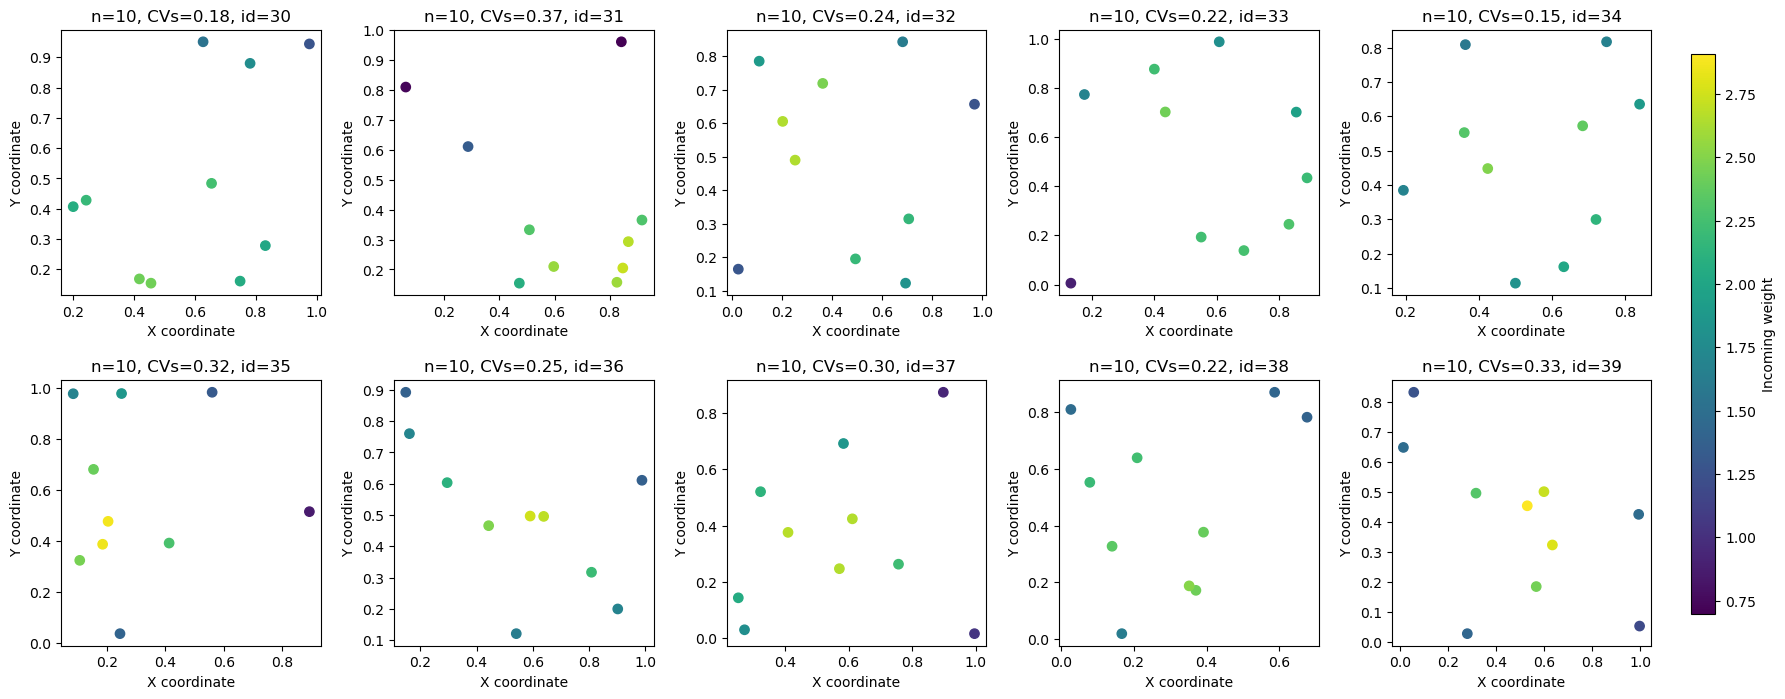

In [20]:
# plot coordinates of the generated patches
import pickle 
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
n = 10

def graph_properties(weights):
    # calculate CV of closeness centrality and strength centrality. 
    s = weights.sum(axis=0)  # strength centrality
    # Only take log on positive weights
    closeness = np.full(weights.shape, 0, dtype=float)
    pos = weights > 0
    closeness[pos] = (weights.shape[0]-1)/(-np.log(weights[pos]).sum(axis=0))

    CVc = np.std(closeness)/np.mean(closeness)
    CVs = np.std(s)/np.mean(s)
    return CVc, CVs

with open(f'./dispersal_weights/uniform_dispersal_weights_patchnum{n}.pkl', 'rb') as f:
    weights_collection = pickle.load(f)
with open(f'./dispersal_weights/uniform_dispersal_coords_patchnum{n}.pkl', 'rb') as f:
    coordinates_collection = pickle.load(f)

# plot the coordinates.
id = np.arange(30,40)  # between 0 and 99

# Compute a fixed color scale across all selected samples
incoming_min = np.inf
incoming_max = -np.inf
for sample_id in id:
    incoming_weights = np.sum(weights_collection[sample_id], axis=0)
    incoming_min = min(incoming_min, incoming_weights.min())
    incoming_max = max(incoming_max, incoming_weights.max())

# plot in subplots
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i in range(len(id)):
    # calculate incoming weights for each patch
    weights = weights_collection[id[i]]
    incoming_weights = np.sum(weights, axis=0)
    ax = axes[i]
    coords = coordinates_collection[id[i]]
    CVc, CVs = graph_properties(weights)

    # color each point by its incoming weight with fixed limits
    ax.scatter(
        coords[:, 0],
        coords[:, 1],
        c=incoming_weights,
        cmap='viridis',
        s=45,
        vmin=incoming_min,
        vmax=incoming_max
    )
    ax.set_title(f'n={n}, CVs={CVs:.2f}, id={id[i]}')
    ax.set_xlabel('X coordinate')
    ax.set_ylabel('Y coordinate')

# Reserve space on the right, then draw a dedicated shared colorbar axis
fig.subplots_adjust(right=0.92, wspace=0.28, hspace=0.32)
norm = Normalize(vmin=incoming_min, vmax=incoming_max)
sm = plt.cm.ScalarMappable(norm=norm, cmap='viridis')
sm.set_array([])
cbar_ax = fig.add_axes([0.94, 0.15, 0.012, 0.7])
fig.colorbar(sm, cax=cbar_ax, label='Incoming weight')

plt.show()

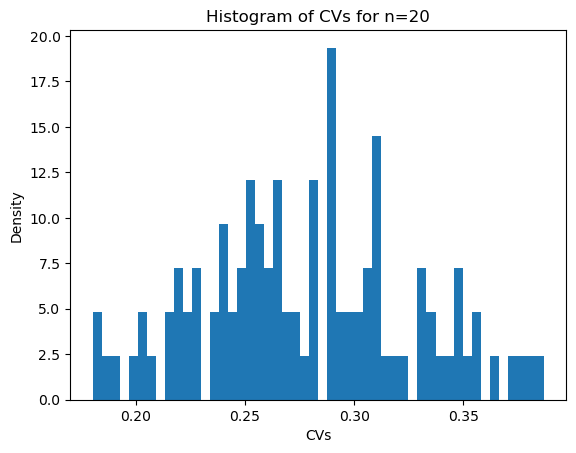

[0.33569258733027624, 0.27248323479706477, 0.21989926626595557, 0.30502227046277997, 0.3199464360007656, 0.259393094240364, 0.3487930355353904, 0.3752588813050646, 0.2468733883607847, 0.23623338377911526, 0.25621833238365843, 0.26337583776872364, 0.30592476368024785, 0.26804130394158693, 0.37212456002863725, 0.33095652481816557, 0.2403453430241626, 0.26798572761582234, 0.29079107933211945, 0.3361300051286571, 0.28091599493100977, 0.2542841764513006, 0.22202110995564928, 0.31072463221003005, 0.28838651832802426, 0.23668383154277559, 0.2221337578390937, 0.24720152775307472, 0.220623337933798, 0.34501820361496843, 0.26082429822193287, 0.25193189327322946, 0.28896773004426674, 0.23985316067299298, 0.3021853891015289, 0.34789014410864166, 0.23840867585885106, 0.21980969846158804, 0.3034377168695851, 0.29851844296925617, 0.27898968485705844, 0.288655118190031, 0.30848558634260215, 0.2659435206266811, 0.36528853543313605, 0.2633425427128708, 0.2512134489037597, 0.1987919785584871, 0.203554077

(array([0.18019536, 0.24350417, 0.27620462, 0.30947585, 0.38192259]),
 [99, 83, 40, 89, 85],
 array([0.18019536, 0.24375357, 0.27898968, 0.30945684, 0.38187206]))

In [ ]:

ns = [5,10,20]
for n in ns:
    with open(f'./dispersal_weights/uniform_dispersal_weights_patchnum{n}.pkl', 'rb') as f:
        weights_collection = pickle.load(f)

    CVc_collection = []
    CVs_collection = []
    for i in range(len(weights_collection)):
        # calculate cvs cvc
        weights = weights_collection[i]
        CVc, CVs = graph_properties(weights)
        CVc_collection.append(CVc)
        CVs_collection.append(CVs)

    plt.hist(CVs_collection, bins=50, density=True)
    plt.xlabel('CVs')
    plt.ylabel('Density')
    plt.title(f'Histogram of CVs for n={n}')
    plt.show()
    print(CVs_collection)
    # get IDs at percentile ranks (not first value >= percentile threshold)
    arr = np.asarray(CVs_collection)
    qs = np.array([0, 25, 50, 75, 99])
    percentiles = np.percentile(arr, qs)

    sorted_idx = np.argsort(arr)
    rank_pos = np.rint((qs / 100.0) * (len(arr) - 1)).astype(int)
    percentile_ids = sorted_idx[rank_pos].tolist()
    percentile_values = arr[percentile_ids]

    percentiles, percentile_ids, percentile_values
    print(f"Percentiles: {percentiles}")
    print(f"Percentile IDs: {percentile_ids}")
    print(f"Percentile Values: {percentile_values}")